In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyAPES.utils.constants import SPECIFIC_HEAT_AIR, MOLAR_MASS_AIR, \
                                    LATENT_HEAT_VAPORISATION, LATENT_HEAT_FUSION, LATENT_HEAT_SUBLIMATION, \
                                    T_MELT, STEFAN_BOLTZMANN, VON_KARMAN, \
                                    GAS_CONSTANT, MOLAR_MASS_H2O, \
                                    SATURATION_VAPOR_PRESSURE_MELT, R_RATIO

In [2]:
Ua = np.array([0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])  # m/s
zU1 = 3.0
zT1 = 3.0
fsnow = 1.0
z0sn = 0.001
z0sf = 0.1

z0g = (z0sn**fsnow) * (z0sf**(1 - fsnow))
z0h = 0.1 * z0g

ustar = np.maximum(
    VON_KARMAN * Ua / np.log(zU1 / z0g),
    0.001)            # ustar should not be 0
ga = VON_KARMAN * ustar / np.log(zT1 / z0h)

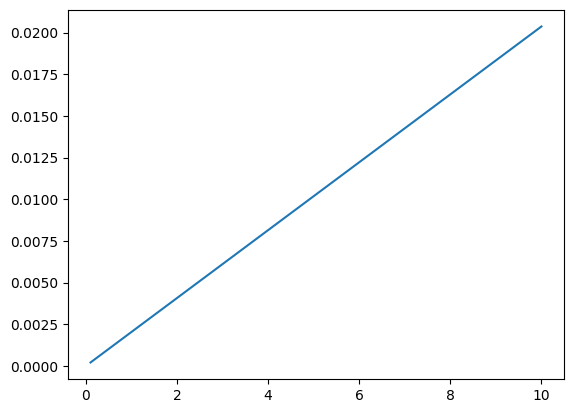

In [3]:
plt.plot(Ua, ga)

In [4]:
from pyAPES.microclimate.micromet import e_sat

In [5]:
def e_sat_old(T: float) -> Tuple:
    """
    Saturation vapor pressure and slope of vapor pressure curve

    Reference:
        Campbell & Norman, 1998. Introduction to Environmental Biophysics. Springer

    Args:
        T (float|array): [degC], air temperature
    
    Returns:
        (tuple):
            esa (float|array): [Pa], saturation vapor pressure over water film
            s (float|array): [Pa K-1], slope of saturation vapor pressure curve

    """
    T_arr = np.asarray(T)

    # Over water at T >= 0 C, over ice at T < 0 C.
    esa_w = 611.0 * np.exp((17.502 * T_arr) / (T_arr + 240.97))  # Pa
    s_w = 17.502 * 240.97 * esa_w / ((240.97 + T_arr)**2)
    
    esa = esa_w
    s = s_w

    if np.isscalar(T):
        return float(esa), float(s)
    
    return esa, s

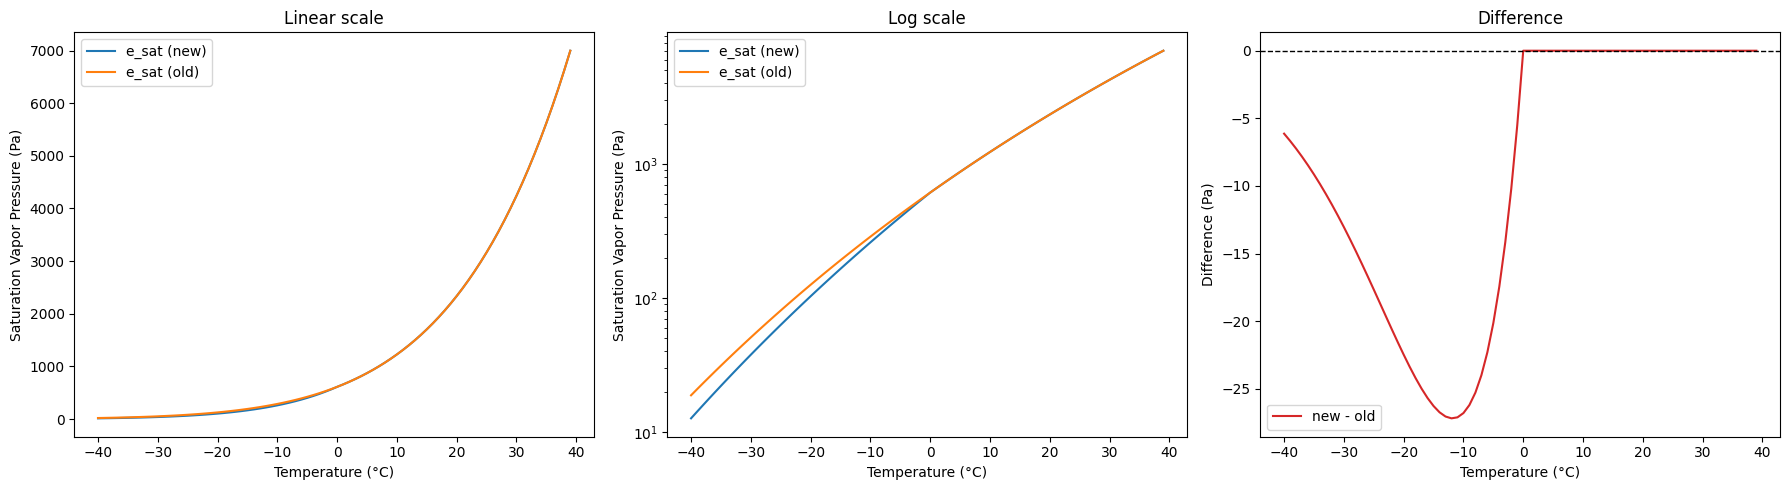

In [11]:
T = np.arange(-40, 40, 1)
esa_new, _ = e_sat(T)
esa_old, _ = e_sat_old(T)
delta = esa_new - esa_old

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

ax1.plot(T, esa_new, label='e_sat (new)')
ax1.plot(T, esa_old, label='e_sat (old)')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Saturation Vapor Pressure (Pa)')
ax1.set_title('Linear scale')
ax1.legend()

ax2.plot(T, esa_new, label='e_sat (new)')
ax2.plot(T, esa_old, label='e_sat (old)')
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Saturation Vapor Pressure (Pa)')
ax2.set_yscale('log')
ax2.set_title('Log scale')
ax2.legend()

ax3.plot(T, delta, color='tab:red', label='new - old')
ax3.axhline(0, color='black', linestyle='--', linewidth=1)
ax3.set_xlabel('Temperature (°C)')
ax3.set_ylabel('Difference (Pa)')
ax3.set_title('Difference')
ax3.legend()

plt.tight_layout()
plt.show()